In [1]:
import pandas as pd
import polars as pl
import numpy as np
import joblib
from lightgbm import LGBMClassifier

In [7]:
import json
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
import polars as pl
from sklearn.metrics import roc_auc_score

with open('../feature_selection/magic_25_features.json' , 'r') as f:
    features = json.load(f)

lazy_df = pl.scan_parquet('../dataset/final_train_data/final_data.parquet')

num_cols = [c for c in features if "_mean" in c or "_last" in c or "_delta" in c]
lazy_df = lazy_df.with_columns([
    (pl.col(c) * 100).floor() / 100 for c in num_cols
])

cols_to_load = features + ["target"]
final_df = lazy_df.select(cols_to_load).collect()

X = final_df.select(features).to_pandas()
y = final_df["target"].to_pandas()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

model = LGBMClassifier(
    boosting_type='dart',
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=7,
    is_unbalance=True,   
    device="gpu",          
    random_state=42,
    importance_type='gain'
)

print("Training final model...")
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

y_pred = model.predict_proba(X_test)[:, 1]
final_auc = roc_auc_score(y_test, y_pred)

print(f"\nFinal Model AUC: {final_auc:.4f}")

Training final model...


c:\Users\HP\OneDrive\Desktop\Coding\AI_PROJECT\venv\Lib\site-packages\lightgbm\callback.py:333: UserWarning: Early stopping is not available in dart mode
  _log_warning("Early stopping is not available in dart mode")


[100]	valid_0's auc: 0.948899	valid_0's binary_logloss: 0.361428
[200]	valid_0's auc: 0.950586	valid_0's binary_logloss: 0.340741
[300]	valid_0's auc: 0.952335	valid_0's binary_logloss: 0.304814
[400]	valid_0's auc: 0.953313	valid_0's binary_logloss: 0.294131
[500]	valid_0's auc: 0.954201	valid_0's binary_logloss: 0.284329
[600]	valid_0's auc: 0.954787	valid_0's binary_logloss: 0.279577
[700]	valid_0's auc: 0.955527	valid_0's binary_logloss: 0.274255
[800]	valid_0's auc: 0.95605	valid_0's binary_logloss: 0.271327
[900]	valid_0's auc: 0.956392	valid_0's binary_logloss: 0.2695
[1000]	valid_0's auc: 0.956495	valid_0's binary_logloss: 0.269154

Final Model AUC: 0.9565


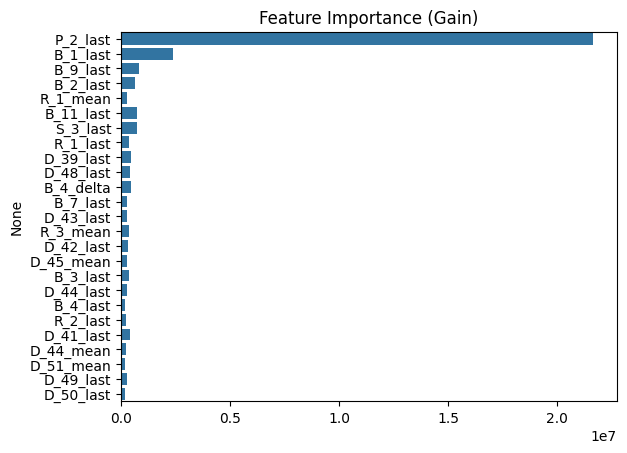

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

importance = model.feature_importances_
feature_names = X_train.columns

sns.barplot(x=importance, y=feature_names)
plt.title("Feature Importance (Gain)")
plt.show()